In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)  # Set print options for numpy arrays

In [11]:
hoop_stress_approx = lambda r, t, p_i, p_o: (p_i-p_o) * r / t

def hoop_stress_exact(r_i, r_o, p_i, p_o):
    A = (p_i * r_i**2 - p_o * r_o**2) / (r_o**2 - r_i**2)
    B = ((p_i - p_o)*(r_i**2 * r_o**2 )) / (r_o**2 - r_i**2)
    return A + B / r_i**2

To calculate the radius ratio `s` for which the error in the hoop stress approximation is less than 1%. It does this by:

1.  the exact hoop stress using `hoop_stress_exact`.
2. Calculating the approximate hoop stress using `hoop_stress_approx`.
3. Computing the peCalculatingrcentage error between the exact and approximate values.
4. Finding the values of `s` where the error is bae is no repetition.

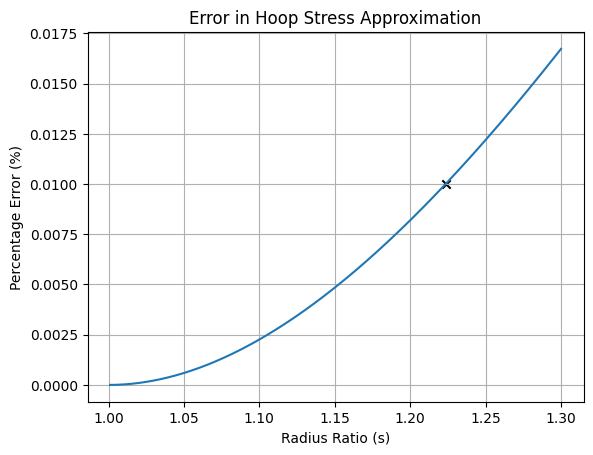

Radius ratio 's' for which the error is less than 1%: [1.001 1.001 1.001 ... 1.223 1.223 1.223]


In [ ]:
p_i = 100  # inner pressure in MPa
r_i = 1  # inner radius in meters
n=3000
t = np.linspace(0.001, 0.3, n)  # thickness in meters
r_o = r_i + t  # outer radius
s = r_o / r_i  # radius ratio
threshold = 0.01  # error threshold (1%)
r = (r_i + r_o)/2 # average radius

def find_s_ratio(n=3000):
    """This function calculates the radius ratio 's' for which the hoop stress
    approximation error is less than 1%.
    The function uses a range of thickness values to compute the outer radius
    and then calculates the radius ratio."""

    exact = hoop_stress_exact(r_i, r_o, p_i, 0)
    approx = hoop_stress_approx(r, t, p_i, 0)
    error = np.abs(exact - approx) / exact # percentage error
    s_cond = s[error < threshold]  # condition for acceptable error
    # plot a graph of error against radius ratio
    plt.plot(s, error)
    plt.scatter(s_cond[-1],threshold, marker='x', color='k',zorder=1)
    plt.xlabel('Radius Ratio (s)')
    plt.ylabel('Percentage Error (%)')
    plt.title('Error in Hoop Stress Approximation')
    plt.grid()
    plt.show()

    return s_cond


# Example usage
s_ratio = find_s_ratio()
print("Radius ratio 's' for which the error is less than 1%:", s_ratio)


### Graph of error against magnitude of pressure

Magnitude of pressure difference: [1.96  1.959 1.958 ... 0.186 0.186 0.186]
Calculating error for radius ratio s=1.00 with r_i=1 and r_o=1.00
Exact hoop stress: [90073.088 90048.183 90023.278 ... 15434.077 15409.172 15384.268]
Approximate hoop stress: [90074.06  90049.183 90024.306 ... 15517.017 15492.14  15467.263]
Calculating error for radius ratio s=1.05 with r_i=1 and r_o=1.05
Exact hoop stress: [1992.824 1992.246 1991.668 ...  260.53   259.952  259.374]
Approximate hoop stress: [1992.595 1992.044 1991.494 ...  343.263  342.713  342.163]
Calculating error for radius ratio s=1.10 with r_i=1 and r_o=1.10
Exact hoop stress: [1033.022 1032.709 1032.396 ...   95.185   94.872   94.559]
Approximate hoop stress: [1031.647 1031.362 1031.077 ...  177.721  177.436  177.151]
Calculating error for radius ratio s=1.15 with r_i=1 and r_o=1.15
Exact hoop stress: [709.122 708.898 708.675 ...  39.387  39.164  38.94 ]
Approximate hoop stress: [706.654 706.459 706.264 ... 121.735 121.54  121.345]
Calc

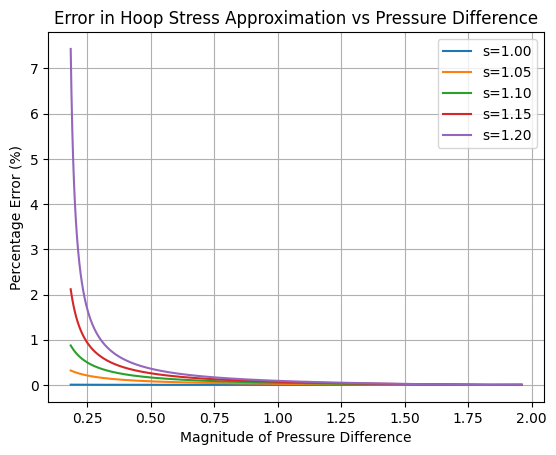

In [45]:
p_o = np.linspace(1, p_i*.83, n)  # outer pressure in MPa
p_magnitude = np.abs(p_i - p_o) / ((p_o + p_i)/2)  # magnitude of pressure difference
print("Magnitude of pressure difference:", p_magnitude)

def error_pressure(r_i, r_o, p_i, p_o):
    r = (r_i + r_o) / 2  # average radius
    t = r_o - r_i
    exact = hoop_stress_exact(r_i, r_o, p_i, p_o)
    print("Exact hoop stress:", exact)
    approx = hoop_stress_approx(r, t, p_i, p_o)
    print("Approximate hoop stress:", approx)
    error = np.abs(exact - approx) / exact  # percentage error
    return error

# Example usage of error_pressure function
for s in s_ratio[1::500]:  # iterate through a subset of s_ratio for clarity
    r_o = s * r_i  # outer radius based on the radius ratio
    print(f"Calculating error for radius ratio s={s:.2f} with r_i={r_i} and r_o={r_o:.2f}")
    error_values = error_pressure(r_i, r_o, p_i, p_o)
    # print(f"Radius ratio s={s:.2f}, Error values:", error_values)
    # Plotting the error against the magnitude of pressure
    plt.plot(p_magnitude, error_values, label=f's={s:.2f}')

plt.xlabel('Magnitude of Pressure Difference')
plt.ylabel('Percentage Error (%)')
plt.title('Error in Hoop Stress Approximation vs Pressure Difference')
plt.legend()
plt.grid()
plt.show()

## test code

Radius ratio 's' for which error is less than 1%: [1.01  1.013 1.016 1.019]


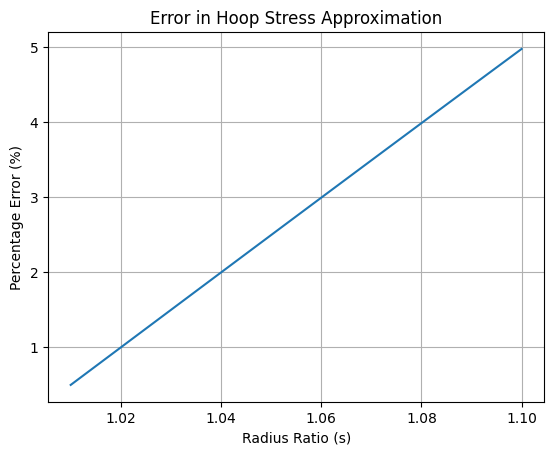

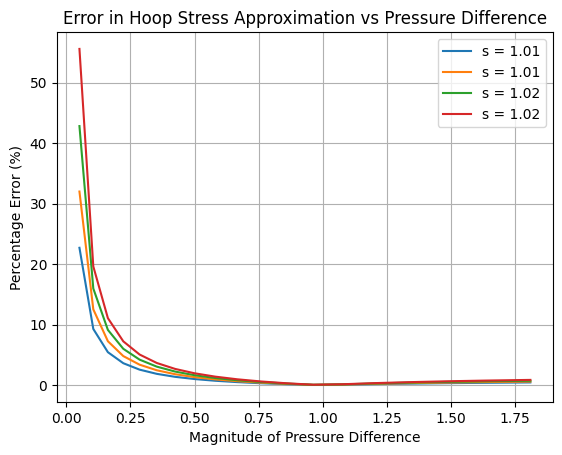

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class ThinCylinder:
    def __init__(self, P_i, P_o, r_i):
        self.P_i = P_i # Inner pressure in MPa
        self.P_o = P_o # Outer pressure in MPa
        self.r_i = r_i # Inner radius in meters
        self.s_ratio = 0.0 # Stress ratio

    def thick_exact(self, r_i, r_o, p_i, p_o):
        """Calculate hoop stresses in a thick-walled cylinder using Lame's equations."""
        A = (p_i * r_i**2 - p_o * r_o**2) / (r_o**2 - r_i**2)
        B = ((p_i - p_o)*(r_i**2 * r_o**2 )) / (r_o**2 - r_i**2)
        return A + B / r_i**2
    
    def thin_approx(self, r_i, r_o, p_i, p_o):
        """ calculate the hoop stresses in a thin-walled cylinder using approximate equations."""
        r = (r_o + r_i) / 2 # Average radius
        t = (r_o - r_i)  # Wall thickness
        return (p_i - p_o) * r_i / t
        
    
    def find_s_ratio(self, n=50):
        """This function calculates the radius ratio 's' for which the hoop stress
        approximation error is less than 1%.
        The function uses a range of thickness values to compute the outer radius
        and then calculates the radius ratio."""
        r_i = self.r_i  # inner radius in meters
        t = np.linspace(0.01, 0.1, n)  # thickness in meters
        r_o = r_i + t  # outer radius
        s = r_o / r_i  # radius ratio

        exact = self.thick_exact(r_i, r_o, self.P_i, 0)
        approx = self.thin_approx(r_i, r_o, self.P_i, 0)
        error = np.abs(exact - approx) / exact * 100  # percentage error
        self.s_ratio = s[error < 1]  # condition for acceptable error
        print(f"Radius ratio 's' for which error is less than 1%: {self.s_ratio}")

        plt.plot(s, error)
        plt.xlabel('Radius Ratio (s)')
        plt.ylabel('Percentage Error (%)')
        plt.title('Error in Hoop Stress Approximation')
        plt.grid()
        plt.show()

    def error_against_pressure(self):
        """This function calculates the error in hoop stress approximation against pressure."""
        r_i = self.r_i  # inner radius in meters
        p_i = self.P_i  # inner pressure in MPa
        s_ratio = np.linspace(1.01, 1.02, 5)  # radius ratio from 1.01 to 2
        p_o = np.arange(1, p_i, 1)  # outer pressure in MPa
        p_magnitude = np.abs(p_i - p_o) / ((p_o + p_i)/2)  # magnitude of pressure difference

        for s in self.s_ratio:
            r_o = s * r_i
            exact = self.thick_exact(r_i, r_o, p_i, p_o)
            approx = self.thin_approx(r_i, r_o, p_i, p_o)
            error = np.abs(exact - approx) / exact * 100
            plt.plot(p_magnitude, error, label=f's = {s:.2f}')

        plt.xlabel('Magnitude of Pressure Difference')
        plt.ylabel('Percentage Error (%)')
        plt.title('Error in Hoop Stress Approximation vs Pressure Difference')
        plt.legend()
        plt.grid()
        plt.show()
        

P_i = 20  # Inner pressure in Pascals
P_o = 0  # Outer pressure in Pascals
r_i = 1.0  # Inner radius in meters

cylinder = ThinCylinder(P_i, P_o, r_i) # Create an instance of ThinCylinder
cylinder.find_s_ratio(30)  # Find radius ratio for acceptable error
cylinder.error_against_pressure()  # Plot error against pressure

In [ ]:
# code for presure difference
p_o = np.linspace(1, P_i * 0.83, 3000)  # outer pressure in MPa
p_magnitude = np.abs(P_i - p_o) / ((p_o + P_i) / 2)

# list of radius ratios from 1.01 to 2
s_ratio = np.linspace(1.01, 2, 1000)  # radius ratio from 1.01 to 2
# outer radius based on raius ratio and fixed inner radius
r_i = 1.0  # fixed inner radius in meters 
r_o = s_ratio * r_i  # outer radius based on the radius ratio